<a href="https://www.kaggle.com/code/siddhrajthakor/customer-churn-prediction-using-ann?scriptVersionId=290385856" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv


# What is customer churn prediction?

**Customer churn prediction is like a crystal ball for businesses, using data to spot customers who are about to leave (churn) so the company can act fast to keep them, often by offering deals or better service, because getting a new customer costs way more than keeping an old one**

**We can use machine learning to to guess which customers are about to leave (churn) a service or product, so the company can try to keep them by offering deals, better support, or fixes, saving money on finding new customers. It works by spotting patterns in past customer behavior (like less app usage, more support tickets) to flag at-risk users before they quit, helping businesses improve loyalty.** 

## Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# i'll add other libraries on the way

## Loading data

In [3]:
df=pd.read_csv('/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Basic EDA

In [4]:
df.shape # to know the size of the data

(10000, 14)

In [5]:
df.info() # to get the basic info about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.describe() # to get statistical info about the data

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.isnull().sum() # to know how many values are null in each feature

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

which means there are no null values in it !

In [8]:
df.duplicated().sum() # to know how many duplicate values are there in our data

np.int64(0)

which means there are no duplicate values in our dataset

## Visual EDA

In [9]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

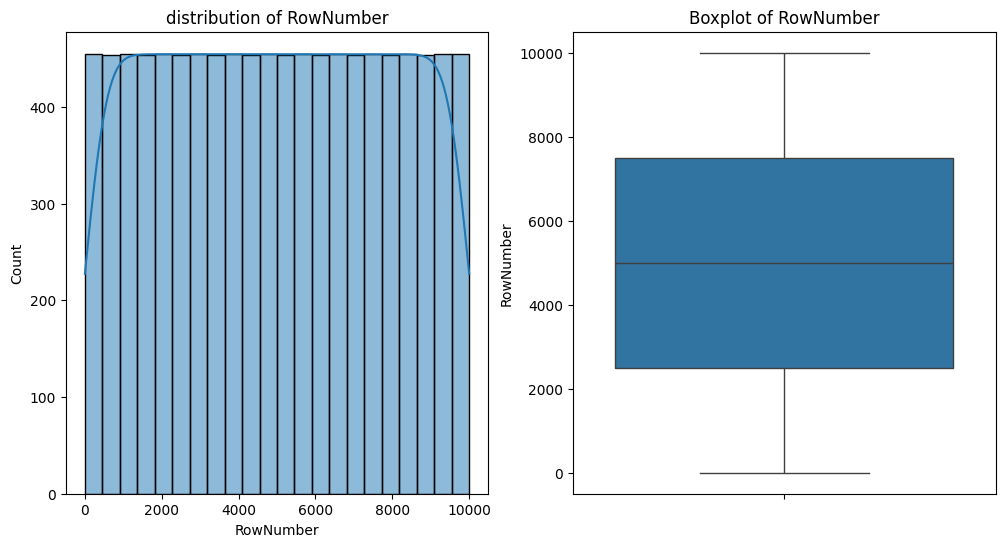

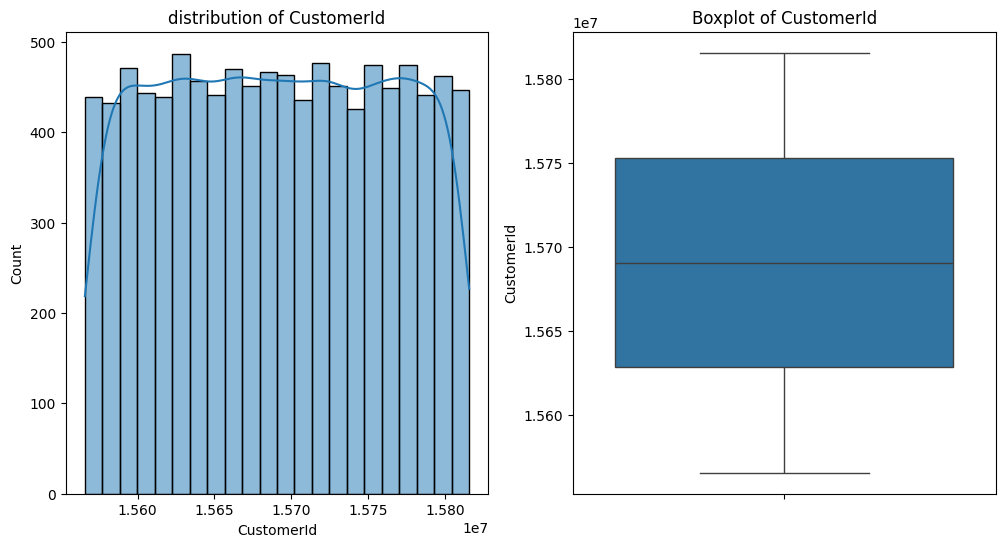

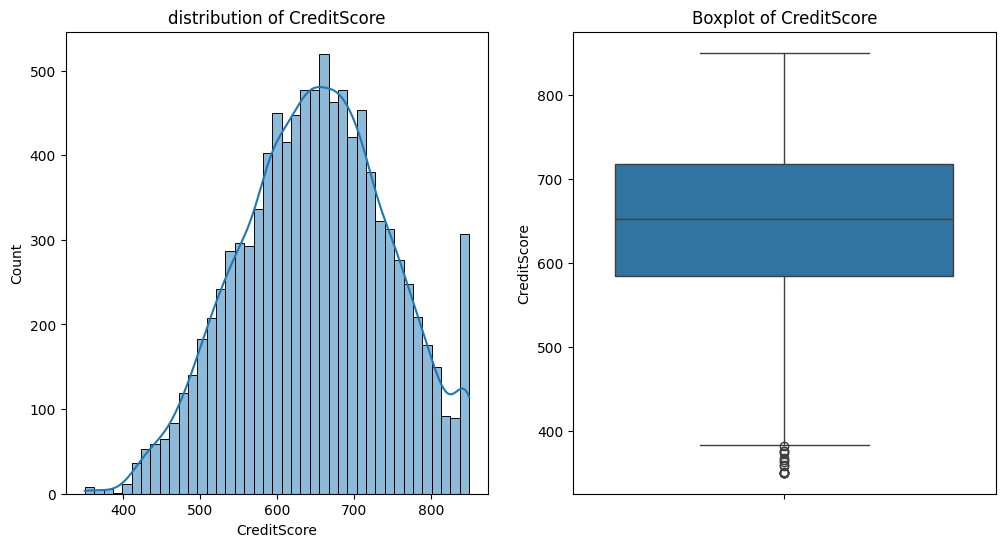

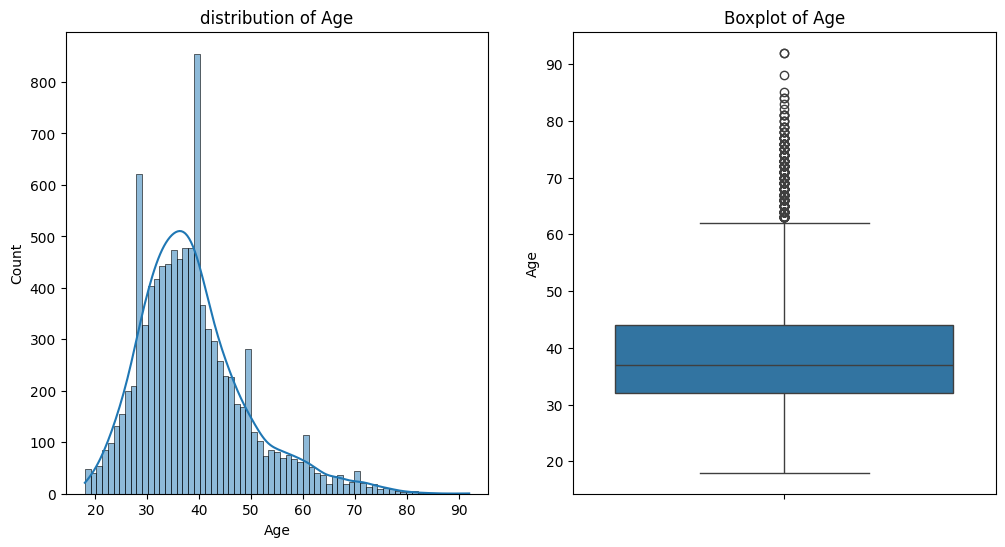

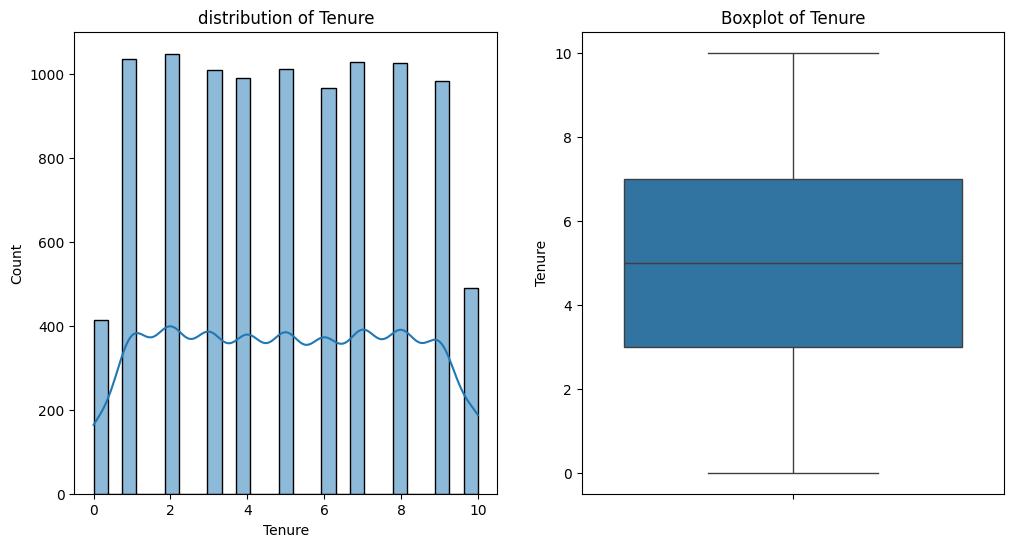

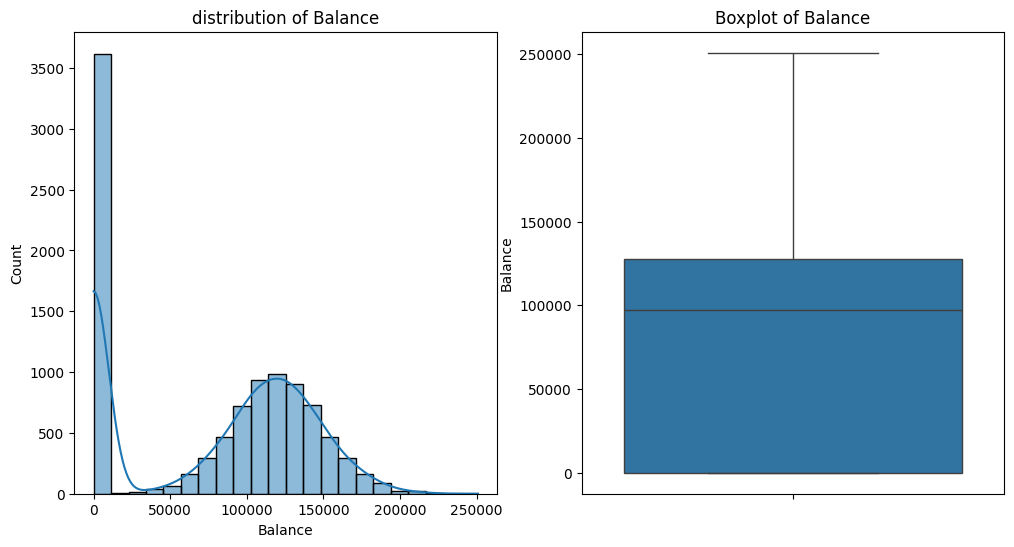

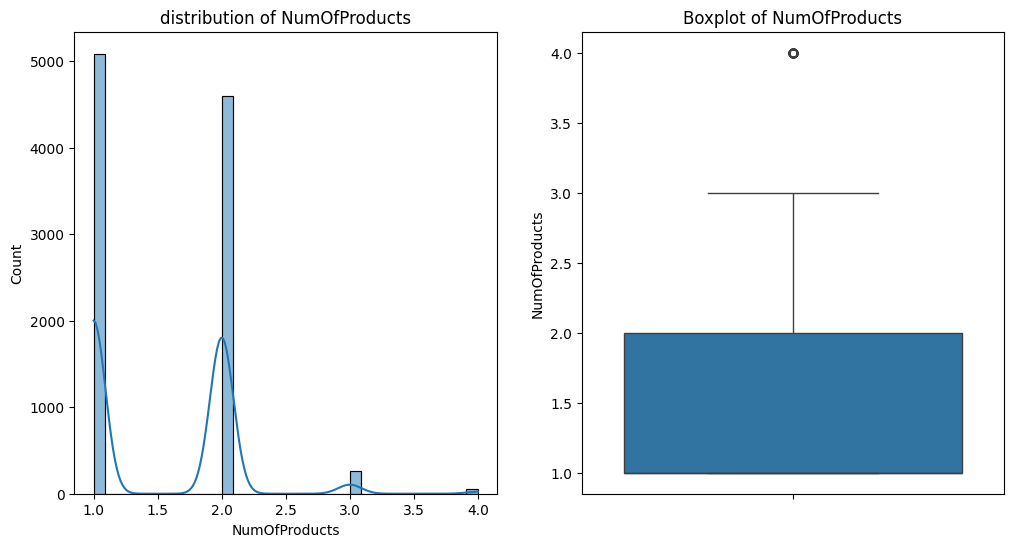

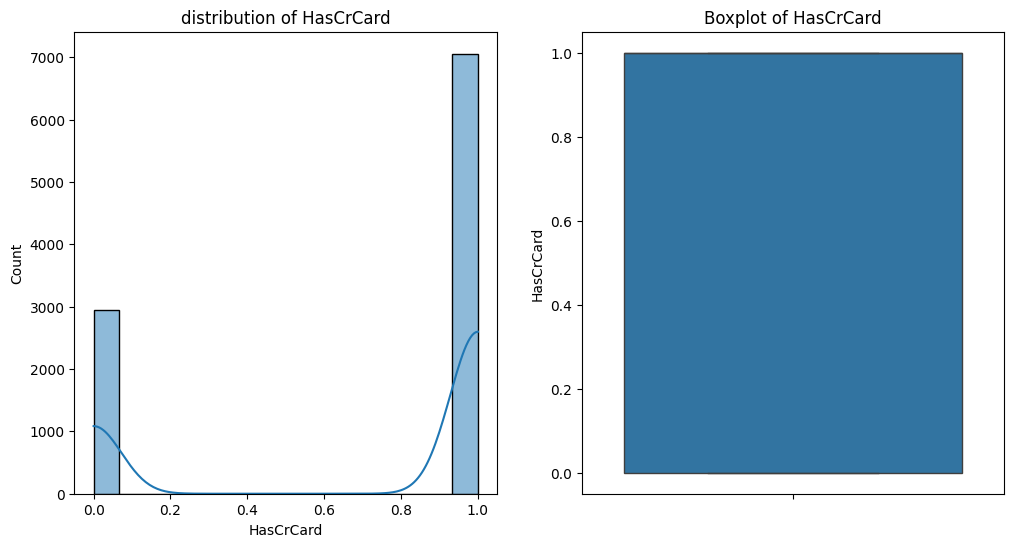

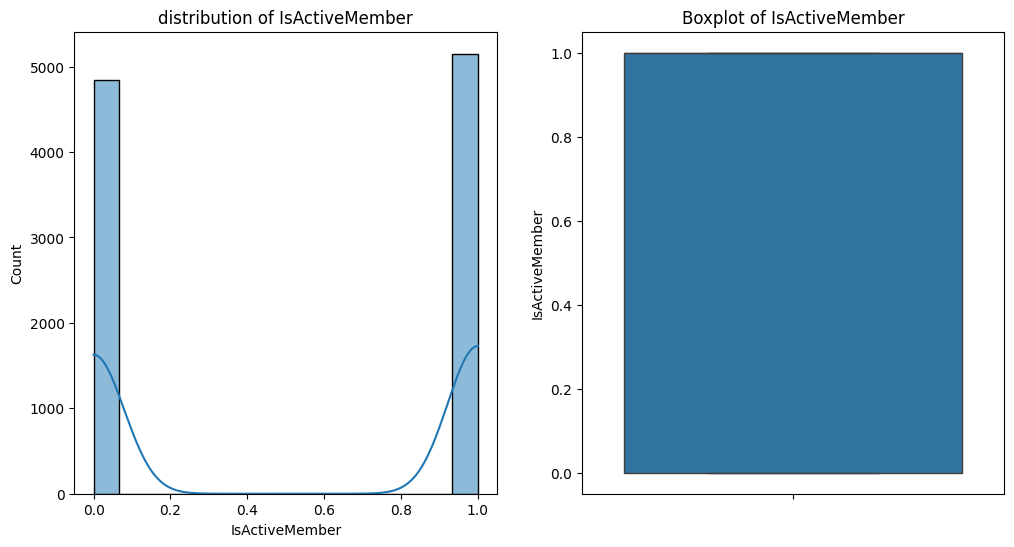

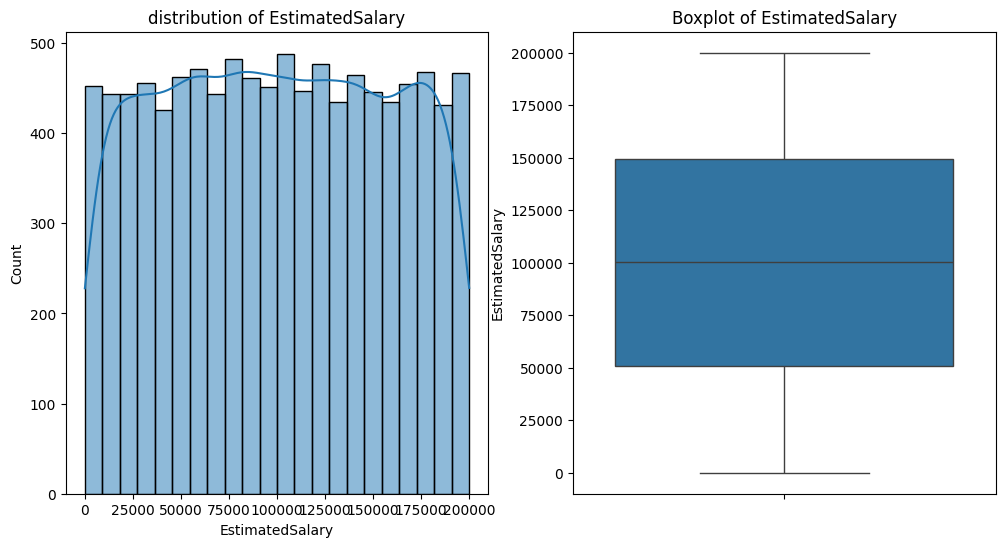

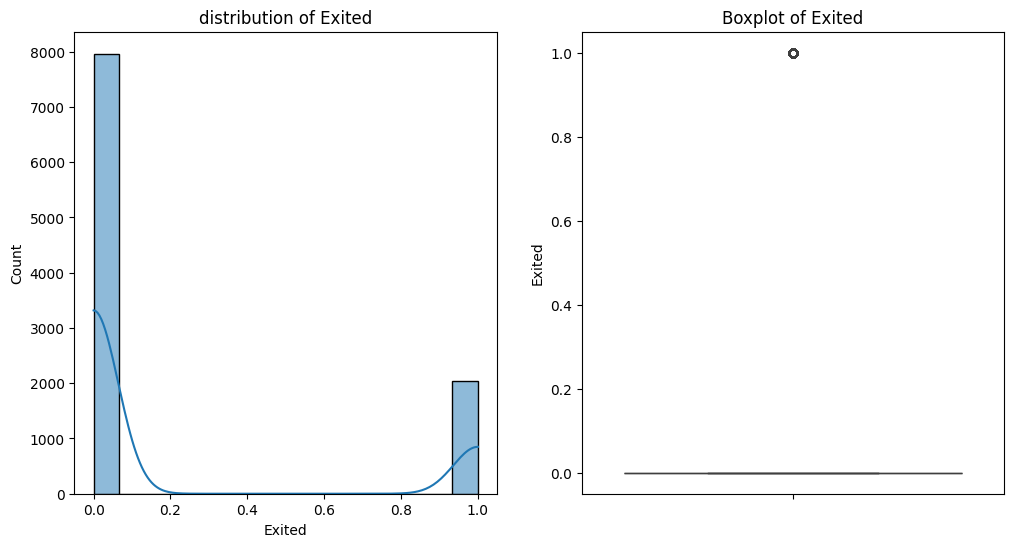

In [10]:
num_cols=df.select_dtypes(include=['int64','float64'])
for i in num_cols:
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    sns.histplot(df[i],kde=True)
    plt.title(f'distribution of {i}')
    
    plt.subplot(1,2,2)
    sns.boxplot(df[i])
    plt.title(f'Boxplot of {i}')
    plt.show()

**here we can see there are many outliers and data is imabanced in terms of exited features which is common in this kind of classfication problems.**

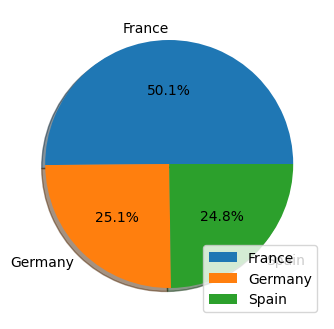

In [11]:
Geography=df['Geography'].value_counts()
plt.figure(figsize=(4,8))
plt.pie(Geography,labels=Geography.index,autopct='%1.1f%%',shadow=True)
plt.legend()
plt.show()

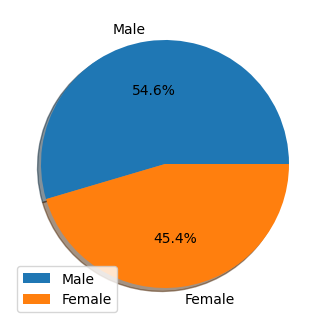

In [12]:
Gender=df['Gender'].value_counts()
plt.figure(figsize=(4,8))
plt.pie(Gender,labels=Gender.index,autopct='%1.1f%%',shadow=True)
plt.legend()
plt.show()

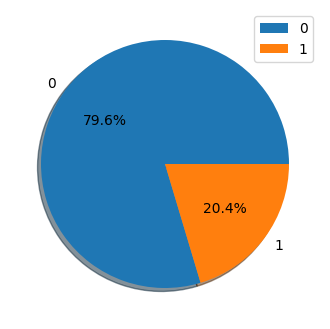

In [13]:
exited = df['Exited'].value_counts()
plt.figure(figsize=(4,8))
plt.pie(exited.values,labels=exited.index,autopct='%1.1f%%',shadow=True)
plt.legend()
plt.show()

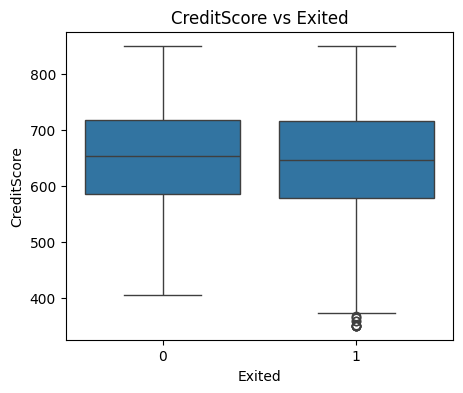

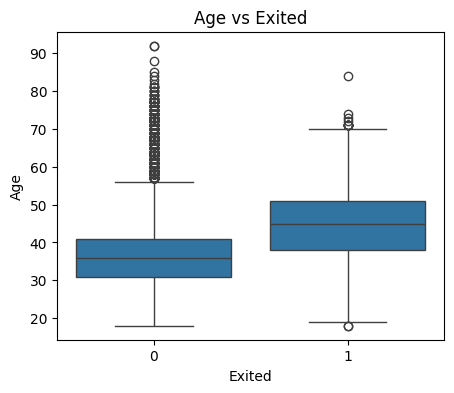

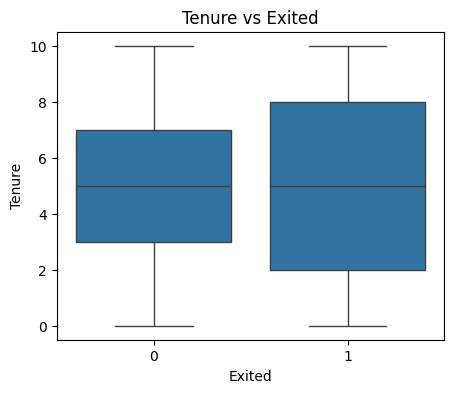

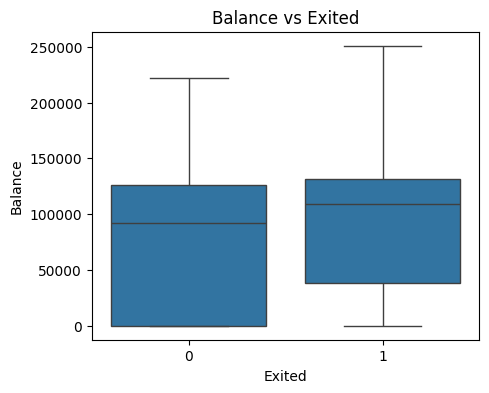

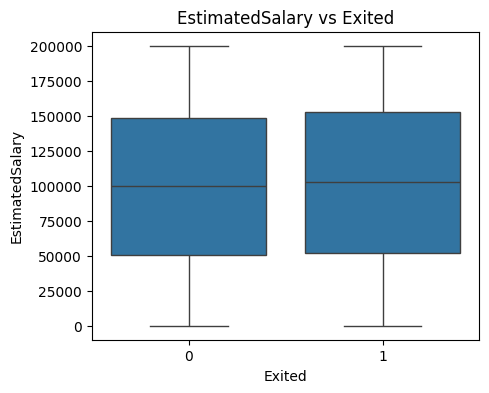

In [14]:
num_cols = ['CreditScore','Age','Tenure','Balance','EstimatedSalary']

for col in num_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(x='Exited', y=col, data=df)
    plt.title(f"{col} vs Exited")
    plt.show()

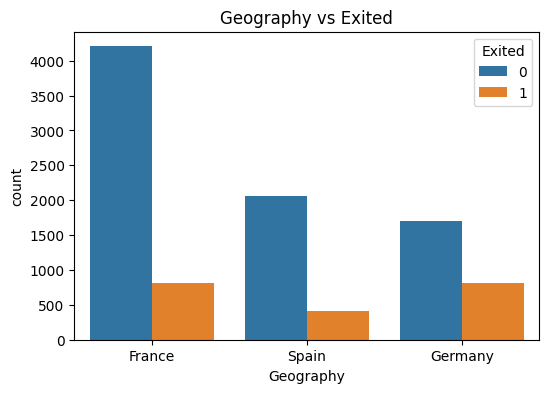

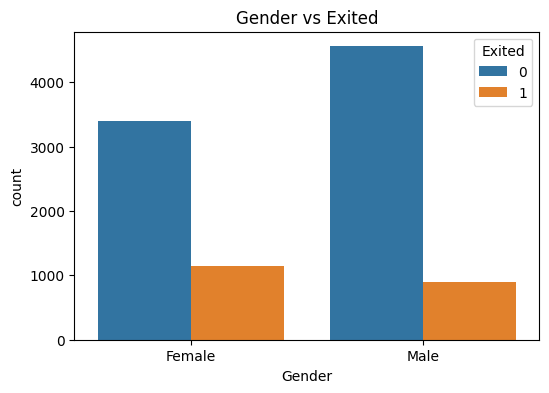

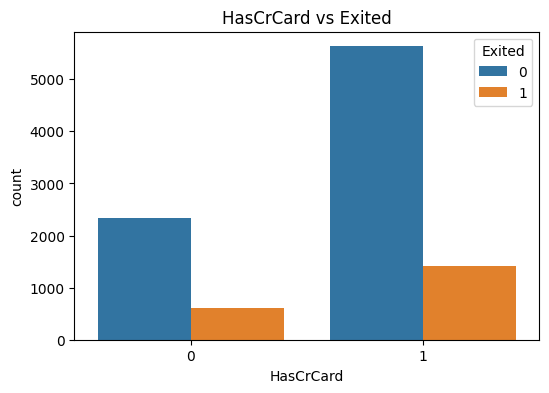

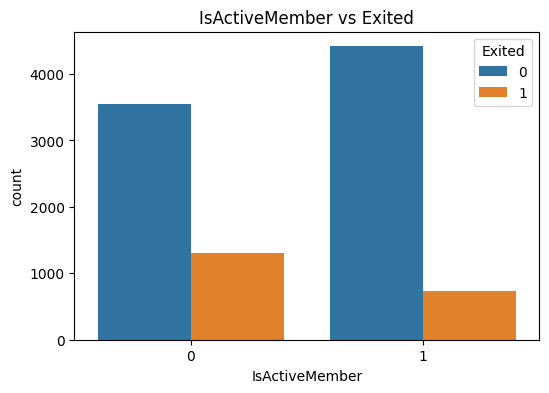

In [15]:
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='Exited')
    plt.title(f"{col} vs Exited")
    plt.show()

In [16]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True) # droping this column cause they cant add any value in model 

In [17]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['Geography']=le.fit_transform(df['Geography'])
df['Gender']=le.fit_transform(df['Gender'])

In [18]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1


### Correlation matrix

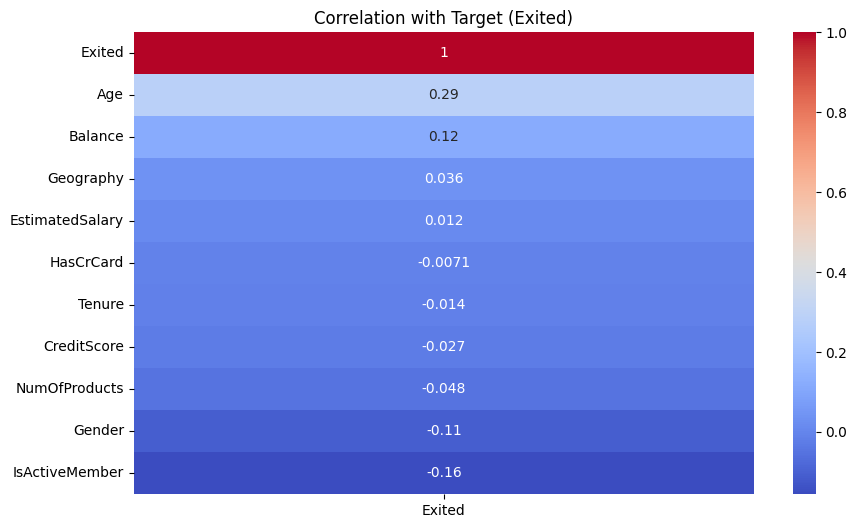

In [19]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr[['Exited']].sort_values(by='Exited', ascending=False),
            annot=True, cmap='coolwarm')
plt.title("Correlation with Target (Exited)")
plt.show()

In [20]:
abs_corr=abs(corr['Exited'])
abs_corr

CreditScore        0.027094
Geography          0.035943
Gender             0.106512
Age                0.285323
Tenure             0.014001
Balance            0.118533
NumOfProducts      0.047820
HasCrCard          0.007138
IsActiveMember     0.156128
EstimatedSalary    0.012097
Exited             1.000000
Name: Exited, dtype: float64

In [21]:
selected_feature=abs_corr[abs_corr>=0.1]
selected_feature

Gender            0.106512
Age               0.285323
Balance           0.118533
IsActiveMember    0.156128
Exited            1.000000
Name: Exited, dtype: float64

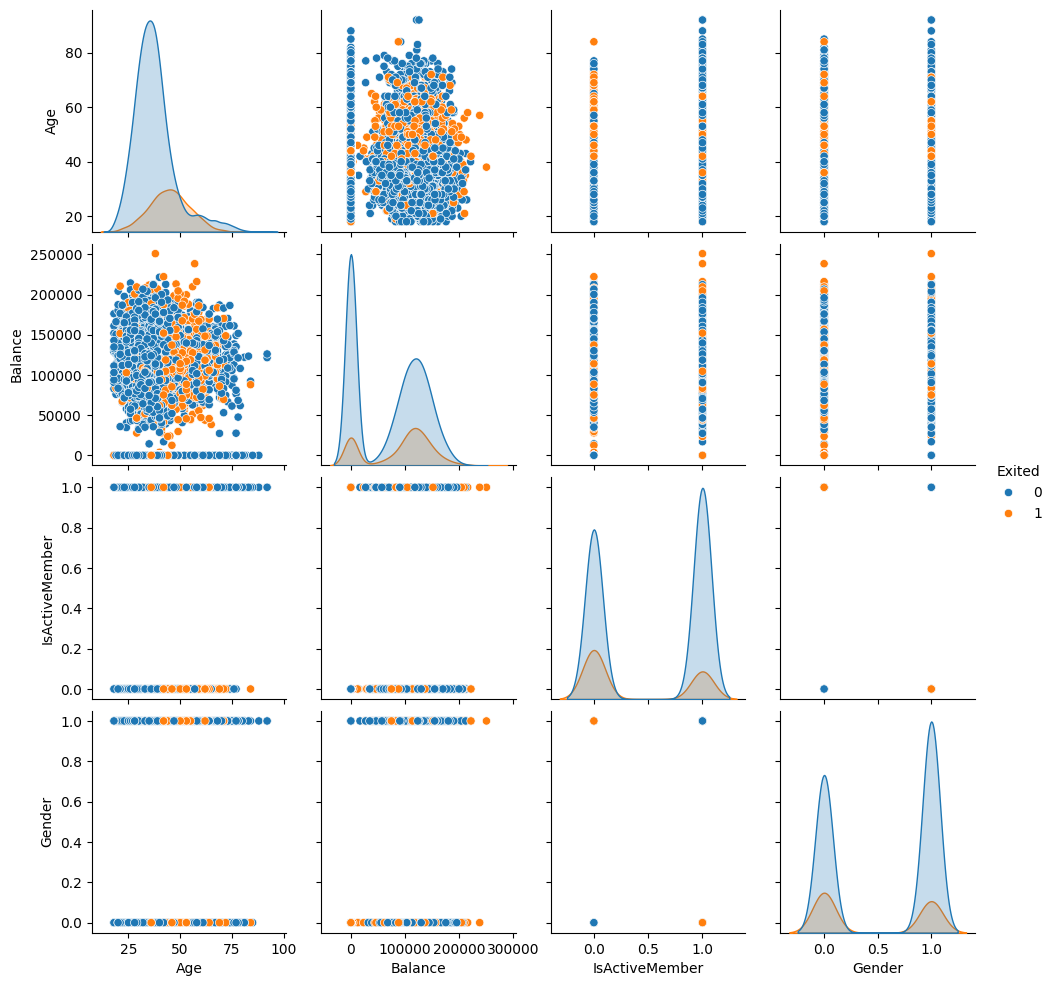

In [22]:
top_features = ['Age', 'Balance', 'IsActiveMember', 'Exited','Gender']
sns.pairplot(df[top_features], hue='Exited', diag_kind='kde')
plt.show()

In [23]:
final_df=df[selected_feature.index]
final_df

,Gender,Age,Balance,IsActiveMember,Exited
0,0,42,0.00,1,1
1,0,41,83807.86,1,0
2,0,42,159660.80,0,1
3,0,39,0.00,0,0
4,0,43,125510.82,1,0
...,...,...,...,...,...
9995,1,39,0.00,0,0
9996,1,35,57369.61,1,0
9997,0,36,0.00,1,1
9998,1,42,75075.31,0,1


## Spliting data

In [24]:
X=final_df.drop(columns=['Exited'])
y=final_df['Exited']

In [25]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [26]:
x_train.shape

(8000, 4)

## Preprocessing

In [27]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [28]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

## Modeling

In [29]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

2026-01-06 16:17:50.987273: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767716271.201546      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767716271.260076      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767716271.778848      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767716271.778899      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767716271.778902      24 computation_placer.cc:177] computation placer alr

In [30]:
model=Sequential() # object of the model

# it is a imput layer where there is 3 perceptron and fixing input_dim to 4 cause we have 4 dim in imnput
model.add(Dense(4,activation='relu',input_dim=4)) 

# hidden layer in between
model.add(Dense(4,activation='relu'))

# output layer
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1767716285.482171      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45 (180.00 B)

 Trainable params: 45 (180.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [33]:
history = model.fit(x_train_scaled,y_train,batch_size=50,epochs=100,verbose=1,validation_split=0.2) 

Epoch 1/100


I0000 00:00:1767716288.132296      69 service.cc:152] XLA service 0x7d30b8007110 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767716288.132334      69 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1767716288.460186      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


 66/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6951 - loss: 0.5816

I0000 00:00:1767716289.142758      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7221 - loss: 0.5707 - val_accuracy: 0.8000 - val_loss: 0.5018
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7917 - loss: 0.5114 - val_accuracy: 0.8000 - val_loss: 0.4688
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7956 - loss: 0.4785 - val_accuracy: 0.8000 - val_loss: 0.4534
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8050 - loss: 0.4424 - val_accuracy: 0.8000 - val_loss: 0.4445
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7904 - loss: 0.4487 - val_accuracy: 0.8000 - val_loss: 0.4380
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7924 - loss: 0.4377 - val_accuracy: 0.8000 - val_loss: 0.4335
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7859 - loss: 0.4479 - val_accuracy: 0.8000 - val_loss: 0.4298
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7998 - loss: 0.4264 - val_accuracy: 0.8037

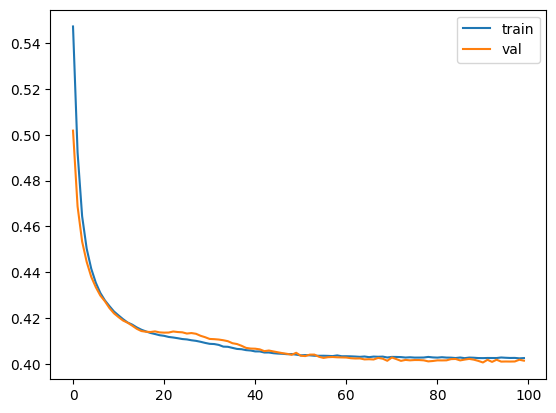

In [34]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

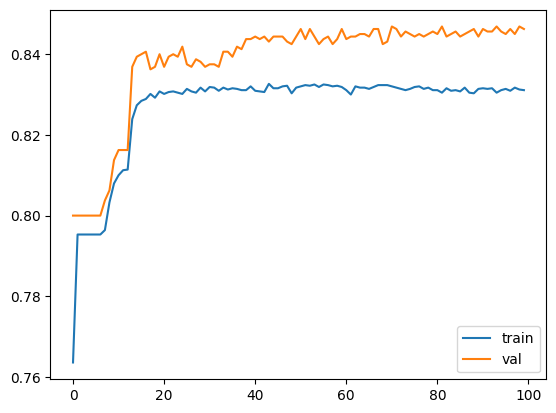

In [35]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()